# Insurance Risk Advisor — Week 1: Exploratory Data Analysis
**Project:** AI-Powered Insurance Policy Advisor & Risk Explainer  
**Author:** Shubham Maheshwari  
**Goal:** Understand the data deeply before building any model. Every insight here becomes a talking point in interviews.

---
## Notebook Structure
1. Setup & Data Loading
2. Data Quality Check
3. Univariate Analysis (individual features)
4. Bivariate Analysis (feature vs target)
5. Correlation Analysis
6. Risk Segmentation (manual, before ML)
7. Key Findings Summary
8. Next Steps

## 1. Setup & Data Loading

In [1]:
# Install dependencies if needed
# !pip install pandas numpy matplotlib seaborn scikit-learn xgboost shap plotly

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 5)

print('All libraries loaded successfully.')

All libraries loaded successfully.


In [6]:
# -------------------------------------------------------------------
# LOAD DATASETS
# Place your downloaded CSVs in the data/raw/ folder
# Dataset 1: https://www.kaggle.com/datasets/teertha/ushealthinsurancedataset
# Dataset 2: https://www.kaggle.com/datasets/ravalsmit/insurance-claims-and-policy-data
# -------------------------------------------------------------------

health_df = pd.read_csv('insurance.csv')           # Health insurance dataset
claims_df = pd.read_csv('data_synthetic.csv')    # Claims & policy dataset

print(f'Health Insurance Dataset: {health_df.shape[0]:,} rows, {health_df.shape[1]} columns')
print(f'Claims Dataset:           {claims_df.shape[0]:,} rows, {claims_df.shape[1]} columns')

Health Insurance Dataset: 1,338 rows, 7 columns
Claims Dataset:           53,503 rows, 30 columns


## 2. Data Quality Check
**Why this matters:** In a real insurance company, dirty data = wrong risk scores = financial loss. Showing you check data quality first impresses interviewers.

In [7]:
def data_quality_report(df, name):
    """Generate a clean data quality report for any dataframe."""
    print(f"\n{'='*55}")
    print(f" DATA QUALITY REPORT: {name}")
    print(f"{'='*55}")
    print(f"\nShape: {df.shape[0]:,} rows x {df.shape[1]} columns")
    print(f"\nData Types:")
    print(df.dtypes)
    
    print(f"\nMissing Values:")
    missing = df.isnull().sum()
    missing_pct = (missing / len(df) * 100).round(2)
    missing_report = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
    print(missing_report[missing_report['Missing Count'] > 0] if missing.sum() > 0 else '  None — clean dataset!')
    
    print(f"\nDuplicate Rows: {df.duplicated().sum():,}")
    print(f"\nNumerical Summary:")
    print(df.describe().round(2))

data_quality_report(health_df, 'Health Insurance')
data_quality_report(claims_df, 'Insurance Claims')


 DATA QUALITY REPORT: Health Insurance

Shape: 1,338 rows x 7 columns

Data Types:
age           int64
sex          object
bmi         float64
children      int64
smoker       object
region       object
charges     float64
dtype: object

Missing Values:
  None — clean dataset!

Duplicate Rows: 1

Numerical Summary:
           age      bmi  children   charges
count  1338.00  1338.00   1338.00   1338.00
mean     39.21    30.66      1.09  13270.42
std      14.05     6.10      1.21  12110.01
min      18.00    15.96      0.00   1121.87
25%      27.00    26.30      0.00   4740.29
50%      39.00    30.40      1.00   9382.03
75%      51.00    34.69      2.00  16639.91
max      64.00    53.13      5.00  63770.43

 DATA QUALITY REPORT: Insurance Claims

Shape: 53,503 rows x 30 columns

Data Types:
Customer ID                            int64
Age                                    int64
Gender                                object
Marital Status                        object
Occupation          

In [8]:
# Preview both datasets
print('--- Health Insurance (first 5 rows) ---')
display(health_df.head())

print('\n--- Claims Dataset (first 5 rows) ---')
display(claims_df.head())

--- Health Insurance (first 5 rows) ---


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520



--- Claims Dataset (first 5 rows) ---


,Customer ID,Age,Gender,Marital Status,Occupation,Income Level,Education Level,Geographic Information,Location,Behavioral Data,...,Customer Preferences,Preferred Communication Channel,Preferred Contact Time,Preferred Language,Risk Profile,Previous Claims History,Credit Score,Driving Record,Life Events,Segmentation Group
0,84966,23,Female,Married,Entrepreneur,70541,Associate Degree,Mizoram,37534,policy5,...,Email,In-Person Meeting,Afternoon,English,1,3,728,DUI,Job Change,Segment5
1,95568,26,Male,Widowed,Manager,54168,Doctorate,Goa,63304,policy5,...,Mail,In-Person Meeting,Morning,French,1,2,792,Clean,Retirement,Segment5
2,10544,29,Female,Single,Entrepreneur,73899,Associate Degree,Rajasthan,53174,policy5,...,Email,Mail,Evening,German,2,1,719,Accident,Childbirth,Segment3
3,77033,20,Male,Divorced,Entrepreneur,63381,Bachelor's Degree,Sikkim,22803,policy5,...,Text,In-Person Meeting,Anytime,French,3,0,639,DUI,Job Change,Segment3
4,88160,25,Female,Separated,Manager,38794,Bachelor's Degree,West Bengal,92858,policy1,...,Email,Text,Weekends,English,0,3,720,Major Violations,Childbirth,Segment2


## 3. Univariate Analysis
**Goal:** Understand the distribution of each feature independently. This tells you what kind of customers/policyholders are in the data.

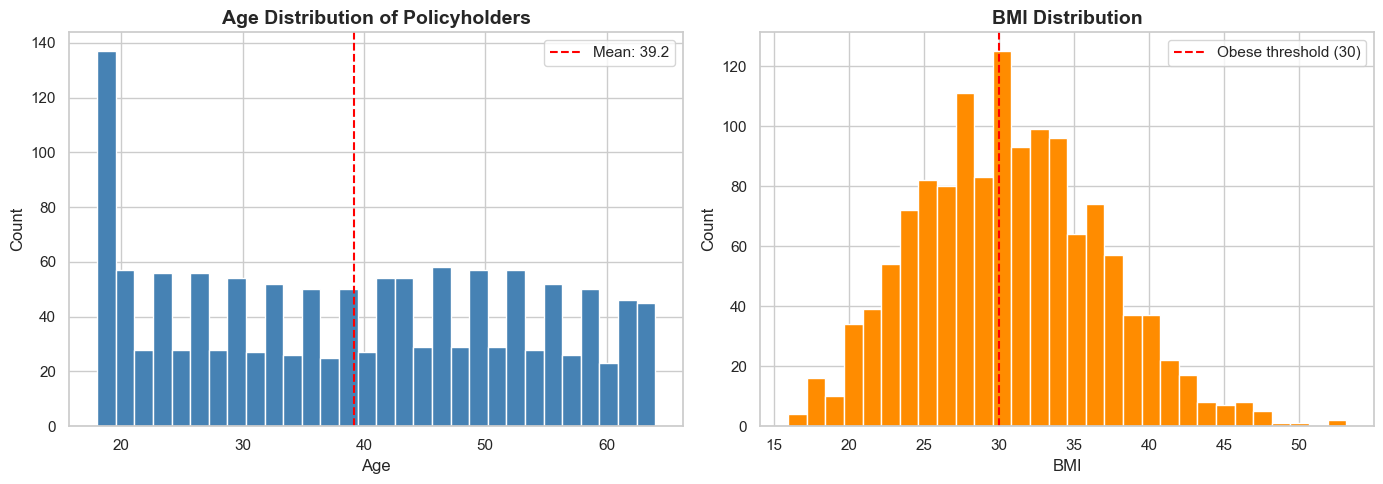


Key Stats:
  Average age: 39.2 years
  Average BMI: 30.7
  Smokers:     274 (20.5%)


In [11]:
# --- Age Distribution ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(health_df['age'], bins=30, color='steelblue', edgecolor='white')
axes[0].set_title('Age Distribution of Policyholders', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Count')
axes[0].axvline(health_df['age'].mean(), color='red', linestyle='--', label=f"Mean: {health_df['age'].mean():.1f}")
axes[0].legend()

# --- BMI Distribution ---
axes[1].hist(health_df['bmi'], bins=30, color='darkorange', edgecolor='white')
axes[1].set_title('BMI Distribution', fontsize=14, fontweight='bold')
axes[1].set_xlabel('BMI')
axes[1].set_ylabel('Count')
axes[1].axvline(30, color='red', linestyle='--', label='Obese threshold (30)')
axes[1].legend()

plt.tight_layout()
plt.savefig('age_bmi_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nKey Stats:")
print(f"  Average age: {health_df['age'].mean():.1f} years")
print(f"  Average BMI: {health_df['bmi'].mean():.1f}")
print(f"  Smokers:     {health_df['smoker'].value_counts()['yes']} ({health_df['smoker'].value_counts(normalize=True)['yes']*100:.1f}%)")

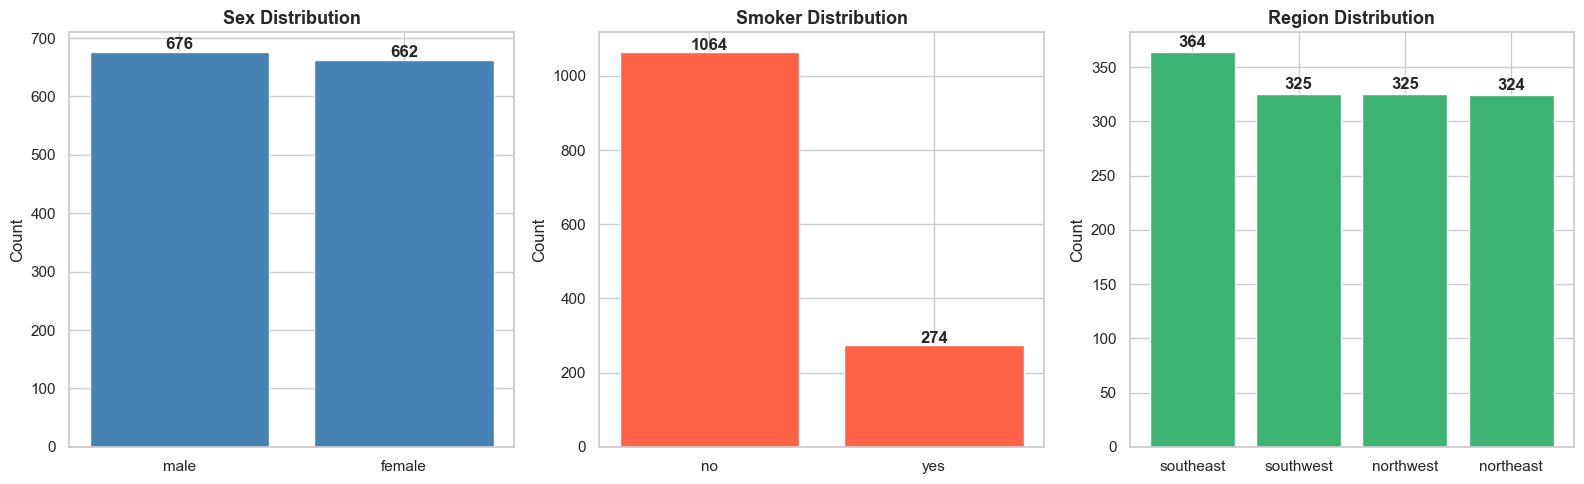

In [12]:
# --- Categorical Features ---
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

cat_cols = ['sex', 'smoker', 'region']
colors = ['steelblue', 'tomato', 'mediumseagreen']

for ax, col, color in zip(axes, cat_cols, colors):
    counts = health_df[col].value_counts()
    ax.bar(counts.index, counts.values, color=color, edgecolor='white')
    ax.set_title(f'{col.capitalize()} Distribution', fontsize=13, fontweight='bold')
    ax.set_ylabel('Count')
    for i, v in enumerate(counts.values):
        ax.text(i, v + 5, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('categorical_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Bivariate Analysis — Feature vs Insurance Charges
**This is the most important section for model building.** We want to know which features most strongly predict insurance charges (our target = risk proxy).

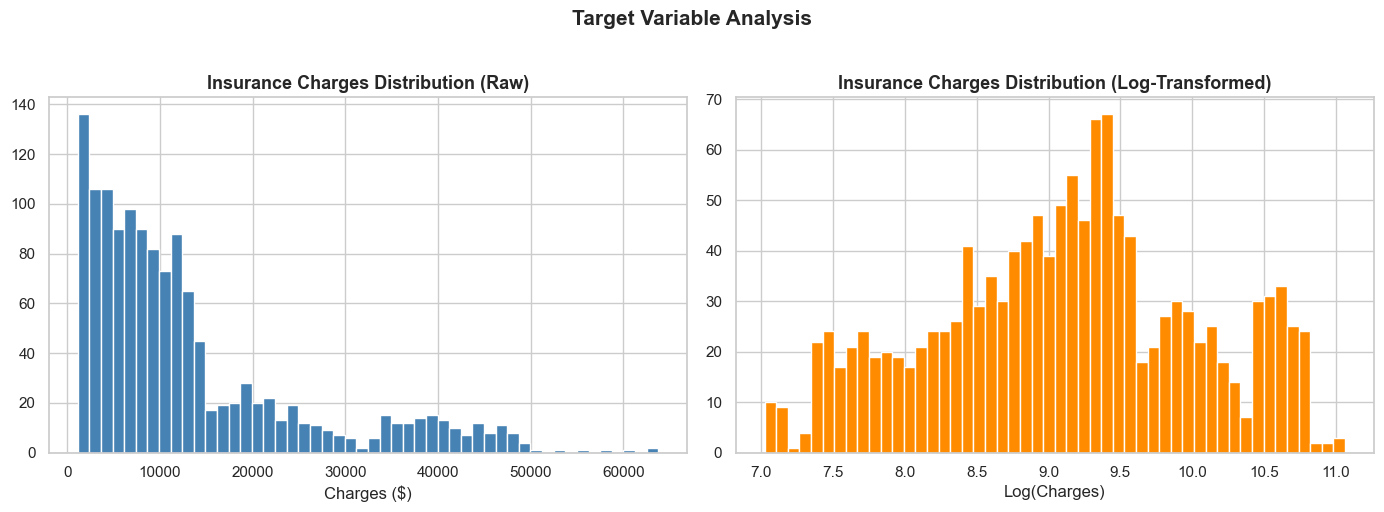


Charges Summary:
  Min:    $1,121.87
  Max:    $63,770.43
  Mean:   $13,270.42
  Median: $9,382.03
  Std:    $12,110.01

  NOTE: Right-skewed distribution — we'll use log-transform in modeling.


In [13]:
# --- Charges Distribution (Target Variable) ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(health_df['charges'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Insurance Charges Distribution (Raw)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Charges ($)')

axes[1].hist(np.log1p(health_df['charges']), bins=50, color='darkorange', edgecolor='white')
axes[1].set_title('Insurance Charges Distribution (Log-Transformed)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Log(Charges)')

plt.suptitle('Target Variable Analysis', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('charges_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nCharges Summary:")
print(f"  Min:    ${health_df['charges'].min():,.2f}")
print(f"  Max:    ${health_df['charges'].max():,.2f}")
print(f"  Mean:   ${health_df['charges'].mean():,.2f}")
print(f"  Median: ${health_df['charges'].median():,.2f}")
print(f"  Std:    ${health_df['charges'].std():,.2f}")
print(f"\n  NOTE: Right-skewed distribution — we'll use log-transform in modeling.")

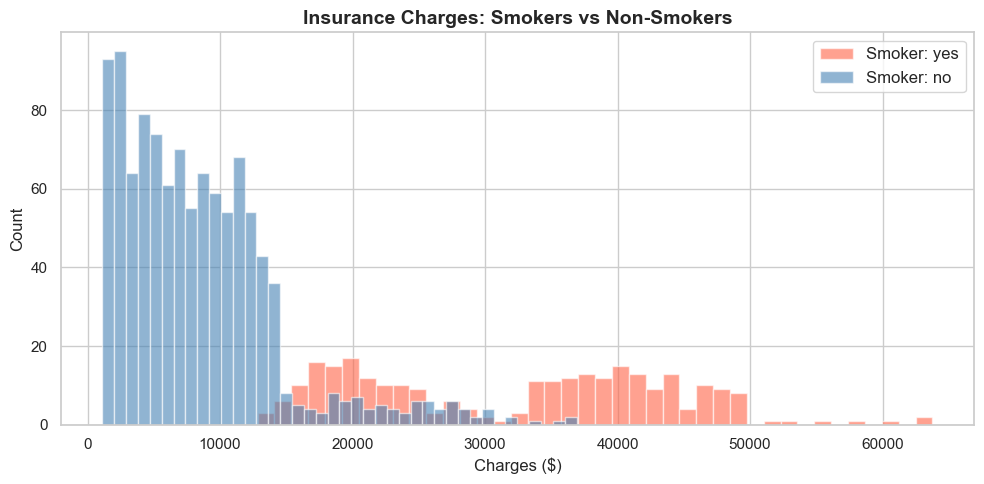


>>> KEY FINDING:
  Smoker average charges:     $32,050.23
  Non-smoker average charges: $8,434.27
  Smokers cost 3.8x more — strongest predictor in the dataset.


In [14]:
# --- KEY INSIGHT: Smoker vs Non-Smoker Charges ---
fig, ax = plt.subplots(figsize=(10, 5))

for smoker_status, color in [('yes', 'tomato'), ('no', 'steelblue')]:
    subset = health_df[health_df['smoker'] == smoker_status]['charges']
    ax.hist(subset, bins=40, alpha=0.6, color=color, label=f"Smoker: {smoker_status}", edgecolor='white')

ax.set_title('Insurance Charges: Smokers vs Non-Smokers', fontsize=14, fontweight='bold')
ax.set_xlabel('Charges ($)')
ax.set_ylabel('Count')
ax.legend(fontsize=12)

smoker_mean = health_df[health_df['smoker']=='yes']['charges'].mean()
non_smoker_mean = health_df[health_df['smoker']=='no']['charges'].mean()

plt.tight_layout()
plt.savefig('smoker_charges.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n>>> KEY FINDING:")
print(f"  Smoker average charges:     ${smoker_mean:,.2f}")
print(f"  Non-smoker average charges: ${non_smoker_mean:,.2f}")
print(f"  Smokers cost {smoker_mean/non_smoker_mean:.1f}x more — strongest predictor in the dataset.")

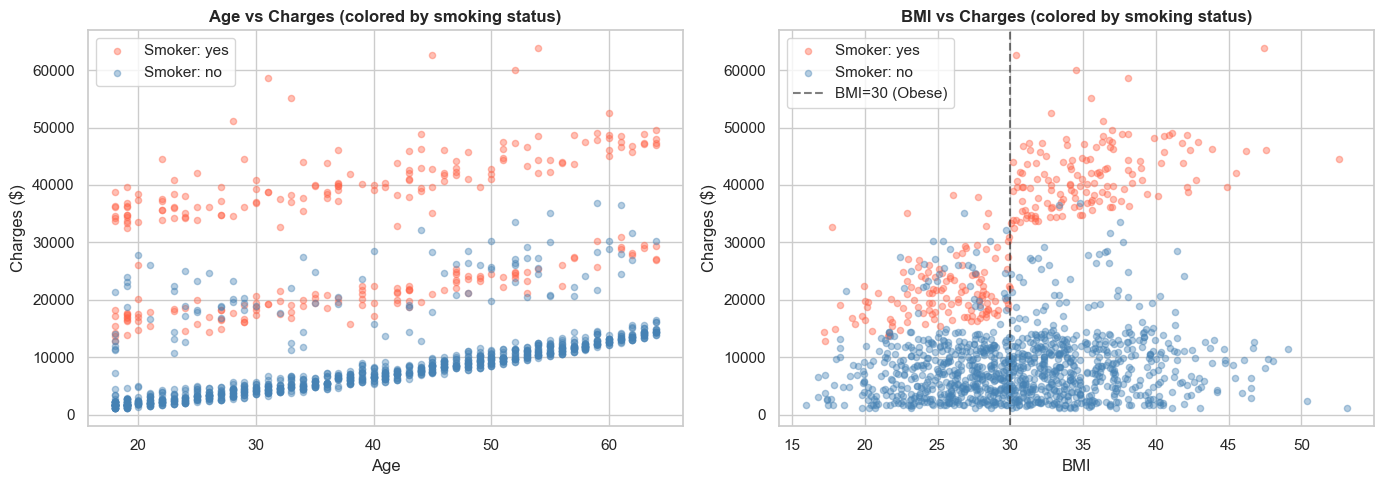

>>> KEY FINDING: Obese smokers (BMI>30, smoker=yes) form a distinct HIGH RISK cluster.
    This is a critical risk segment your AI advisor must flag.


In [15]:
# --- Age vs Charges (scatter) ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors_map = {'yes': 'tomato', 'no': 'steelblue'}
for smoker_status in ['yes', 'no']:
    subset = health_df[health_df['smoker'] == smoker_status]
    axes[0].scatter(subset['age'], subset['charges'], 
                    alpha=0.4, label=f"Smoker: {smoker_status}",
                    color=colors_map[smoker_status], s=20)

axes[0].set_title('Age vs Charges (colored by smoking status)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Charges ($)')
axes[0].legend()

# --- BMI vs Charges ---
for smoker_status in ['yes', 'no']:
    subset = health_df[health_df['smoker'] == smoker_status]
    axes[1].scatter(subset['bmi'], subset['charges'],
                    alpha=0.4, label=f"Smoker: {smoker_status}",
                    color=colors_map[smoker_status], s=20)

axes[1].axvline(30, color='black', linestyle='--', alpha=0.5, label='BMI=30 (Obese)')
axes[1].set_title('BMI vs Charges (colored by smoking status)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('BMI')
axes[1].set_ylabel('Charges ($)')
axes[1].legend()

plt.tight_layout()
plt.savefig('age_bmi_vs_charges.png', dpi=150, bbox_inches='tight')
plt.show()

print(">>> KEY FINDING: Obese smokers (BMI>30, smoker=yes) form a distinct HIGH RISK cluster.")
print("    This is a critical risk segment your AI advisor must flag.")

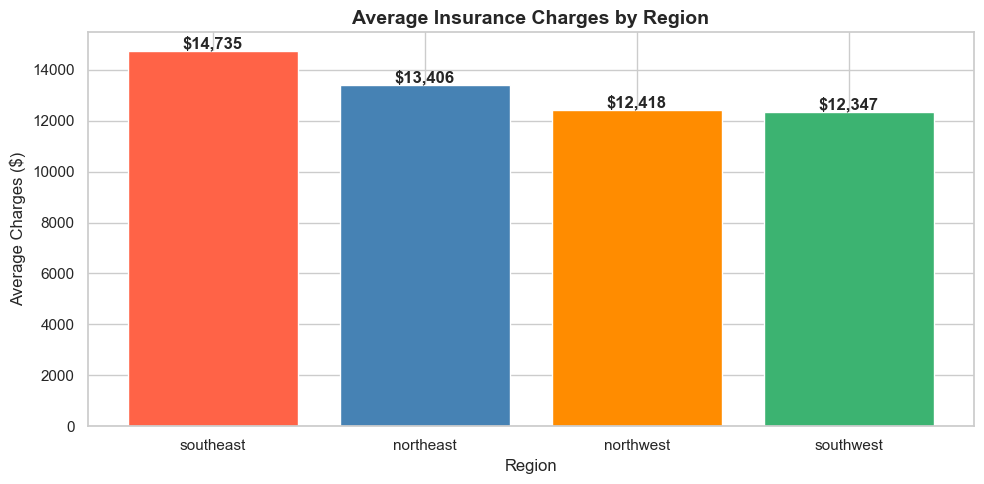


Region Summary:
           Mean Charges  Median Charges  Count
region                                        
southeast      14735.41         9294.13    364
northeast      13406.38        10057.65    324
northwest      12417.58         8965.80    325
southwest      12346.94         8798.59    325


In [16]:
# --- Region Analysis ---
region_stats = health_df.groupby('region')['charges'].agg(['mean', 'median', 'count']).round(2)
region_stats.columns = ['Mean Charges', 'Median Charges', 'Count']
region_stats = region_stats.sort_values('Mean Charges', ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(region_stats.index, region_stats['Mean Charges'], 
               color=['tomato', 'steelblue', 'darkorange', 'mediumseagreen'], edgecolor='white')
ax.set_title('Average Insurance Charges by Region', fontsize=14, fontweight='bold')
ax.set_xlabel('Region')
ax.set_ylabel('Average Charges ($)')
for bar, val in zip(bars, region_stats['Mean Charges']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100, 
            f'${val:,.0f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('region_charges.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nRegion Summary:")
print(region_stats)

## 5. Correlation Analysis

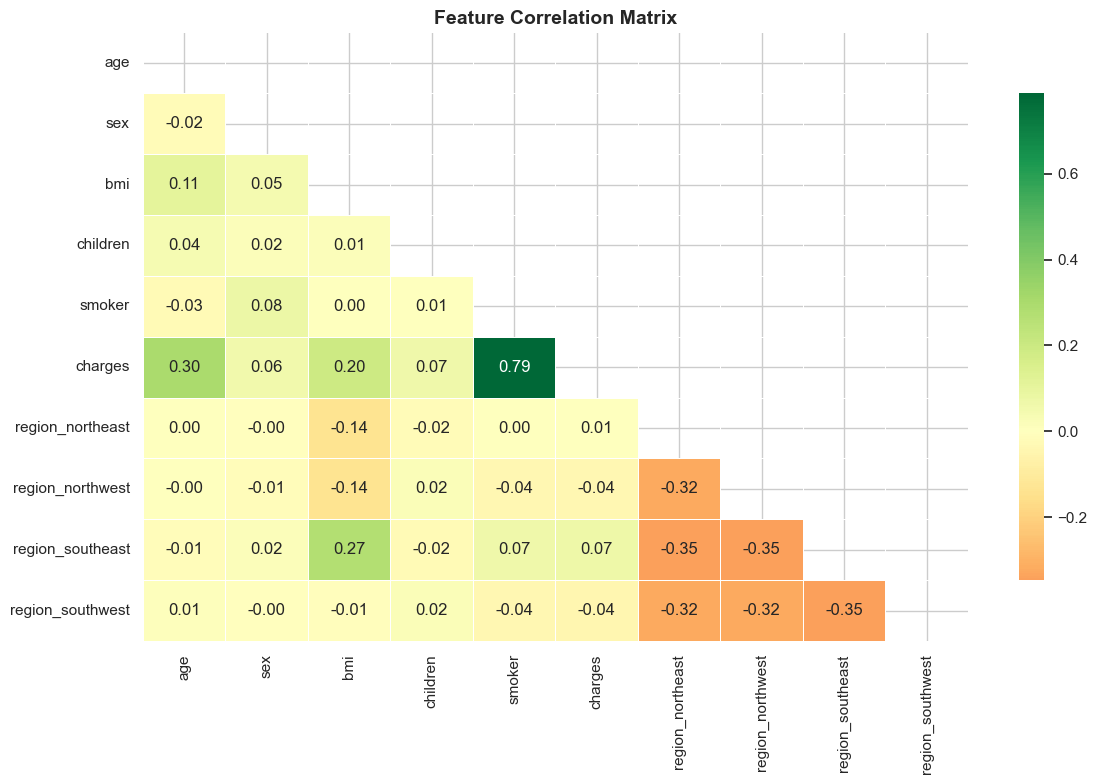


>>> Correlation with 'charges' (target):
  smoker                    +0.787  ███████████████
  age                       +0.299  █████
  bmi                       +0.198  ███
  region_southeast          +0.074  █
  children                  +0.068  █
  sex                       +0.057  █
  region_northeast          +0.006  
  region_northwest          -0.040  
  region_southwest          -0.043  


In [17]:
# Encode categorical for correlation
health_encoded = health_df.copy()
health_encoded['smoker'] = (health_encoded['smoker'] == 'yes').astype(int)
health_encoded['sex'] = (health_encoded['sex'] == 'male').astype(int)
health_encoded = pd.get_dummies(health_encoded, columns=['region'])

corr_matrix = health_encoded.corr()

fig, ax = plt.subplots(figsize=(12, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', 
            cmap='RdYlGn', center=0, ax=ax,
            linewidths=0.5, cbar_kws={'shrink': 0.8})
ax.set_title('Feature Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n>>> Correlation with 'charges' (target):")
target_corr = corr_matrix['charges'].drop('charges').sort_values(ascending=False)
for feat, corr in target_corr.items():
    bar = '█' * int(abs(corr) * 20)
    print(f"  {feat:<25} {corr:+.3f}  {bar}")

## 6. Risk Segmentation (Manual — Before ML)
**This is a key differentiator.** Before the model does it automatically, we define risk segments from domain knowledge. This shows business thinking — not just coding.

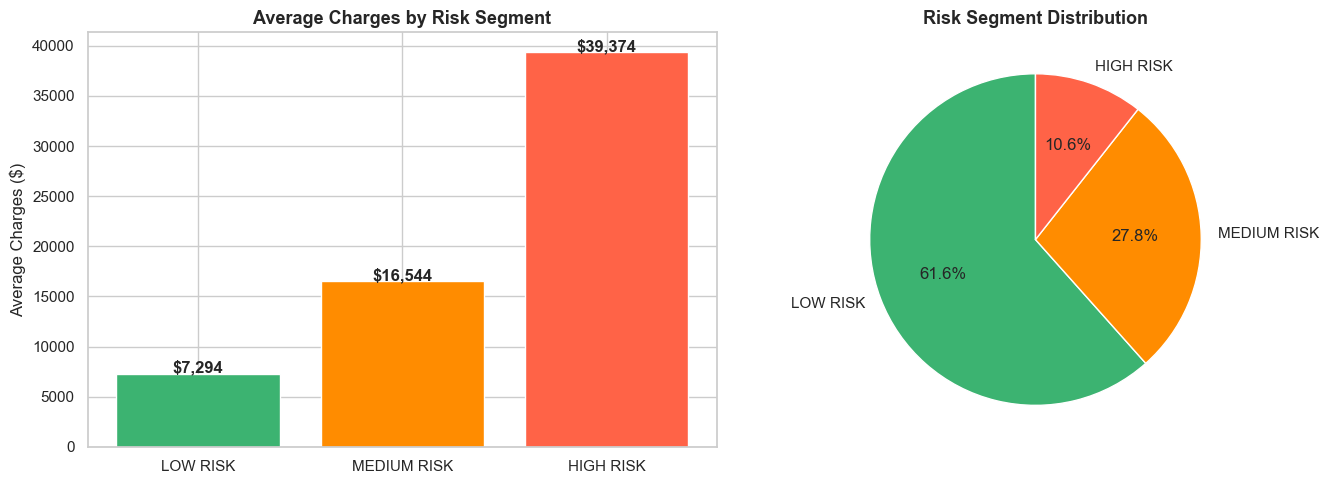


Risk Segment Summary:
              Avg Charges ($)  Count
risk_segment                        
HIGH RISK            39373.97    142
LOW RISK              7294.28    824
MEDIUM RISK          16543.64    372


In [18]:
def assign_risk_segment(row):
    """
    Business rule-based risk segmentation.
    Mirrors how real insurance underwriters manually assess risk.
    """
    score = 0
    
    # Smoking (highest risk factor)
    if row['smoker'] == 'yes':
        score += 3
    
    # BMI risk
    if row['bmi'] >= 35:      # Severely obese
        score += 2
    elif row['bmi'] >= 30:    # Obese
        score += 1
    
    # Age risk
    if row['age'] >= 55:
        score += 2
    elif row['age'] >= 40:
        score += 1
    
    # Dependents (more children = more exposure)
    if row['children'] >= 3:
        score += 1
    
    # Map score to segment
    if score >= 5:
        return 'HIGH RISK'
    elif score >= 3:
        return 'MEDIUM RISK'
    else:
        return 'LOW RISK'

health_df['risk_segment'] = health_df.apply(assign_risk_segment, axis=1)

# Visualize segments
segment_stats = health_df.groupby('risk_segment')['charges'].agg(['mean', 'count'])
segment_stats.columns = ['Avg Charges ($)', 'Count']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = {'LOW RISK': 'mediumseagreen', 'MEDIUM RISK': 'darkorange', 'HIGH RISK': 'tomato'}
segment_order = ['LOW RISK', 'MEDIUM RISK', 'HIGH RISK']

bars = axes[0].bar(segment_order, 
                   [segment_stats.loc[s, 'Avg Charges ($)'] for s in segment_order],
                   color=[colors[s] for s in segment_order], edgecolor='white')
axes[0].set_title('Average Charges by Risk Segment', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Average Charges ($)')
for bar, s in zip(bars, segment_order):
    val = segment_stats.loc[s, 'Avg Charges ($)']
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100, 
                 f'${val:,.0f}', ha='center', fontweight='bold')

axes[1].pie([segment_stats.loc[s, 'Count'] for s in segment_order],
            labels=segment_order,
            colors=[colors[s] for s in segment_order],
            autopct='%1.1f%%', startangle=90)
axes[1].set_title('Risk Segment Distribution', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('risk_segments.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nRisk Segment Summary:")
print(segment_stats.round(2))

## 7. Save Processed Data for Next Notebook

In [19]:
# Add log-transformed target (better for regression)
health_df['log_charges'] = np.log1p(health_df['charges'])

# Save
health_df.to_csv('health_insurance_with_segments.csv', index=False)
print(f'Saved processed dataset: {health_df.shape[0]:,} rows, {health_df.shape[1]} columns')
print(f'\nColumns saved: {list(health_df.columns)}')

Saved processed dataset: 1,338 rows, 9 columns

Columns saved: ['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges', 'risk_segment', 'log_charges']


## 8. Key Findings Summary
**Write this section in your own words. Use these findings in every interview.**

In [20]:
findings = {
    'Dataset Size': f"{len(health_df):,} policyholders",
    'Avg Annual Premium': f"${health_df['charges'].mean():,.2f}",
    'Smoker Premium Multiplier': f"{health_df[health_df['smoker']=='yes']['charges'].mean() / health_df[health_df['smoker']=='no']['charges'].mean():.1f}x higher",
    'High Risk Customers': f"{(health_df['risk_segment']=='HIGH RISK').sum()} ({(health_df['risk_segment']=='HIGH RISK').mean()*100:.1f}%)",
    'Strongest Predictor': 'Smoking status (correlation: ~0.79)',
    'Top Risk Combination': 'Smoker + BMI>30 + Age>55',
    'Log Transform Needed': 'Yes — charges are right-skewed'
}

print('\n' + '='*55)
print(' WEEK 1 KEY FINDINGS')
print('='*55)
for k, v in findings.items():
    print(f"  {k:<30} {v}")

print('\n' + '='*55)
print(' NEXT STEPS (Week 2 Notebook)')
print('='*55)
next_steps = [
    '1. Feature engineering (BMI categories, age groups, interaction terms)',
    '2. Encode categorical variables (one-hot + label encoding)',
    '3. Train XGBoost regression model on log(charges)',
    '4. Evaluate with RMSE, MAE, R2 on test set',
    '5. Add SHAP explainability to understand feature contributions'
]
for step in next_steps:
    print(f'  {step}')


 WEEK 1 KEY FINDINGS
  Dataset Size                   1,338 policyholders
  Avg Annual Premium             $13,270.42
  Smoker Premium Multiplier      3.8x higher
  High Risk Customers            142 (10.6%)
  Strongest Predictor            Smoking status (correlation: ~0.79)
  Top Risk Combination           Smoker + BMI>30 + Age>55
  Log Transform Needed           Yes — charges are right-skewed

 NEXT STEPS (Week 2 Notebook)
  1. Feature engineering (BMI categories, age groups, interaction terms)
  2. Encode categorical variables (one-hot + label encoding)
  3. Train XGBoost regression model on log(charges)
  4. Evaluate with RMSE, MAE, R2 on test set
  5. Add SHAP explainability to understand feature contributions
